In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
# Load the Excel file
df = pd.read_csv('D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\EDA\\data sheets\\tendulkar_ODI.csv')

# Preview the data
print("Initial Data Snapshot:")
print(df[['Runs', '4s']].head())

Initial Data Snapshot:
  Runs 4s
0    0  0
1    0  0
2   36  5
3   19  1
4   31  3


In [3]:
# Clean 'Runs' column
def clean_runs(value):
    if isinstance(value, str):
        if value in ['DNB', 'TDNB']:
            return None
        value = re.sub(r'\*', '', value)
        return int(value) if value.isdigit() else None
    return value

df['Runs_clean'] = df['Runs'].apply(clean_runs)

# Clean '4s' column
df['X4s_clean'] = df['4s'].replace('-', None).astype(float)

# Drop missing values
df_cleaned = df.dropna(subset=['Runs_clean', 'X4s_clean'])

In [5]:
#Univariate Analysis: Runs
runs = df_cleaned['Runs_clean']

print("📈 Runs Summary:")
print(f"Mean: {runs.mean():.2f}")
print(f"Median: {runs.median():.2f}")
print(f"Standard Deviation: {runs.std():.2f}")
print(f"Skewness: {runs.skew():.2f}")

📈 Runs Summary:
Mean: 39.45
Median: 27.50
Standard Deviation: 39.93
Skewness: 1.30


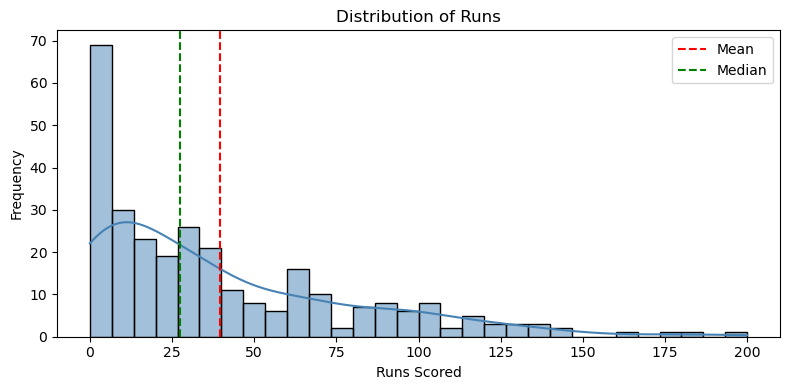

In [6]:
# Histogram
plt.figure(figsize=(8, 4))
sns.histplot(runs, bins=30, kde=True, color='steelblue')
plt.axvline(runs.mean(), color='red', linestyle='--', label='Mean')
plt.axvline(runs.median(), color='green', linestyle='--', label='Median')
plt.title("Distribution of Runs")
plt.xlabel("Runs Scored")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

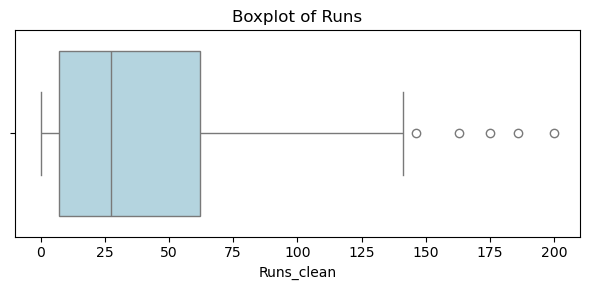

In [7]:
# Boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=runs, color='lightblue')
plt.title("Boxplot of Runs")
plt.tight_layout()
plt.show()

In [8]:
# Univariate Analysis: 4s
x4s = df_cleaned['X4s_clean']

print("\n📈 4s Summary:")
print(f"Mean: {x4s.mean():.2f}")
print(f"Median: {x4s.median():.2f}")
print(f"Standard Deviation: {x4s.std():.2f}")
print(f"Skewness: {x4s.skew():.2f}")


📈 4s Summary:
Mean: 4.51
Median: 3.00
Standard Deviation: 4.73
Skewness: 1.22


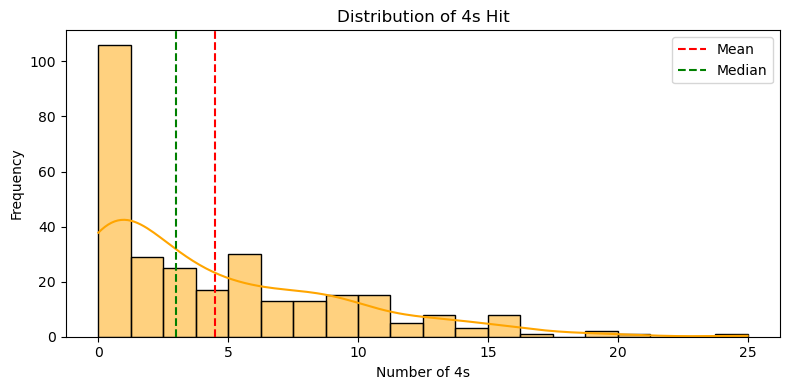

In [9]:
# Histogram
plt.figure(figsize=(8, 4))
sns.histplot(x4s, bins=20, kde=True, color='orange')
plt.axvline(x4s.mean(), color='red', linestyle='--', label='Mean')
plt.axvline(x4s.median(), color='green', linestyle='--', label='Median')
plt.title("Distribution of 4s Hit")
plt.xlabel("Number of 4s")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

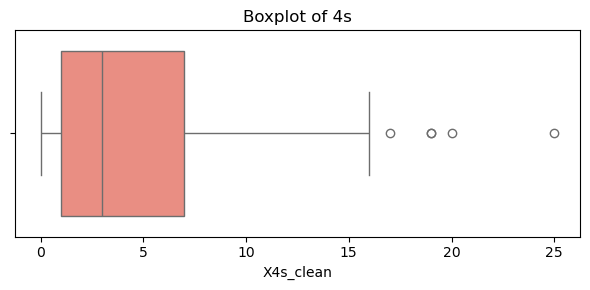

In [10]:
# Boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=x4s, color='salmon')
plt.title("Boxplot of 4s")
plt.tight_layout()
plt.show()

In [11]:

#Metric	Use When…
#Mean	Data is symmetric and free of outliers
#Median	Data is skewed or contains extreme values
#Skewness	Helps decide whether mean or median is better